Total Circular velocity at 8 kpc (MOND) = 241.4 km/s
Enclosed baryonic mass at 200 kpc = 9.15e+10 Msun (should be 9.15e10)


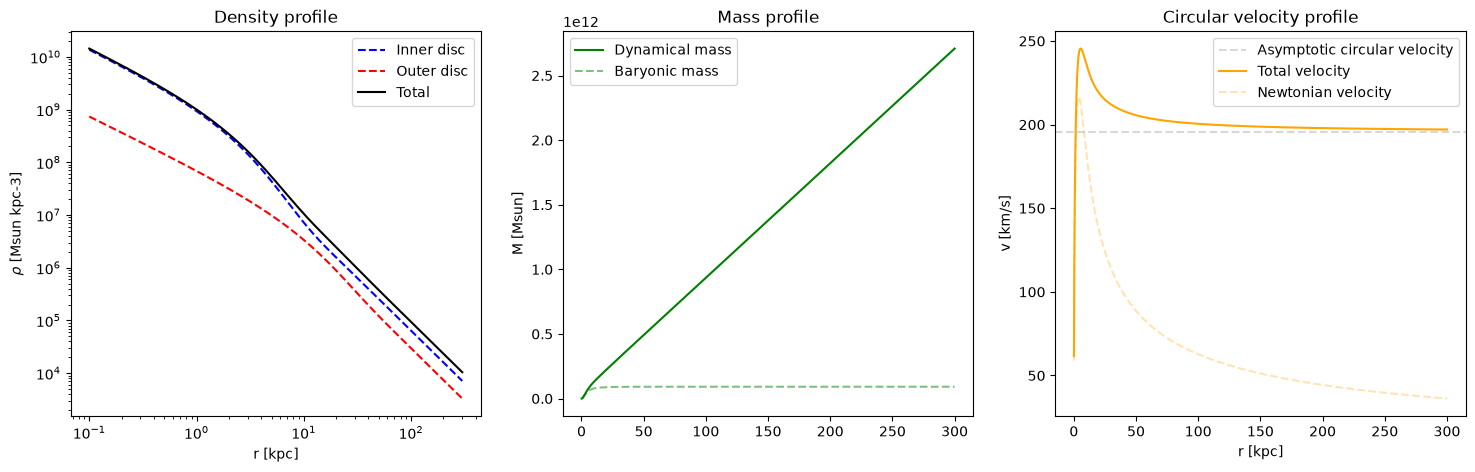

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#constants (hopefully correct)
G         = 4.30091e-3  #pc/M_sol/km/s**2 
a0        = 3.703 #(km/s**2)/pc   
G_kpc     = G * 1e-3 #kpc/M_sol/km/s**2    
a0_kpc    = a0 * 1e3 #(km/s**2)/kpc   

#helper functions
def nu_mond(M_tot, r, rd):
    y = alpha(M_tot, r) * f(r, rd)
    return 0.5 + np.sqrt(0.25 + 1.0/y)

def f(r, rd):
    return 1 - np.exp(-r/rd)*(1 + r/rd)

def df_dr(r, rd):
    return r/(rd**2)* np.exp(-r/rd)

def alpha(M_tot, r):
    return G_kpc*M_tot/(a0_kpc * r**2)

def dnu_dy(M_tot, r, rd):
    y = alpha(M_tot, r) * f(r,rd)
    return -1/(2*y**2*np.sqrt(1/4 + 1/y))

def dnu_dr(M_tot, r, rd):
    dndy = dnu_dy(M_tot, r, rd)
    a = alpha(M_tot, r)
    dfdr = df_dr(r, rd)
    return dndy * a * (dfdr - 2*f(r, rd)/r)

def dMc_dr(M_tot, r, rd):
    dfdr = df_dr(r, rd)
    return M_tot*(f(r, rd) * dnu_dr(M_tot, r, rd) + nu_mond(M_tot, r, rd) * dfdr)

#analytical density profile
def rho_ana(M_tot, r, rd):
    dM_dr = dMc_dr(M_tot, r, rd)
    return 1/(4*np.pi*r**2)* dM_dr

M_MW       = 9.15e10             # Msun — total baryonic mass
f_inner    = 0.8236              # fraction in inner component
f_outer    = 0.1764              # fraction in outer component
Rd_inner   = 1.29/0.6                # kpc AT Z=0???
Rd_outer   = 4.20/0.6                # kpc AT Z=0???

M_inner    = f_inner * M_MW      # 7.54e10 Msun
M_outer    = f_outer * M_MW      # 1.61e10 Msun

r_grid = np.geomspace(0.1, 300, 1000)

def nu(y):
    return 0.5 + np.sqrt(0.25 + 1.0 / np.maximum(y, 1e-30))

M_b_inner = M_inner * f(r_grid, Rd_inner)
M_b_outer = M_outer * f(r_grid, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r_grid**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
vc        = np.sqrt(G_kpc * M_c / r_grid)
vc_newt   = np.sqrt(G_kpc * M_b_total / r_grid)
print(f"Total Circular velocity at 8 kpc (MOND) = {np.interp(8, r_grid, vc):.1f} km/s")
print(f"Enclosed baryonic mass at 200 kpc = {np.interp(200, r_grid, M_b_total):.2e} Msun (should be 9.15e10)")
rho_ana_1 = rho_ana(M_inner, r_grid, Rd_inner)
rho_ana_2 = rho_ana(M_outer, r_grid, Rd_outer)
v_inf_theo = (G_kpc * M_MW * a0_kpc)**0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].loglog(r_grid, rho_ana_1, label="Inner disc", color="blue", ls = "dashed")
axes[0].loglog(r_grid, rho_ana_2, label="Outer disc", color="red", ls ="dashed")
axes[0].loglog(r_grid, rho_ana_1 + rho_ana_2, label="Total", color="black")
axes[0].set_xlabel("r [kpc]")
axes[0].set_ylabel(r"$\rho$ [Msun kpc-3]")
axes[0].set_title("Density profile") 
axes[0].legend()
axes[1].plot(r_grid, M_c, label="Dynamical mass", color="green")
axes[1].plot(r_grid, M_b_total, label="Baryonic mass", color="green",alpha=0.5, ls = "dashed")
axes[1].set_ylabel("M [Msun]")
axes[1].set_title("Mass profile")
axes[1].legend()
axes[2].axhline(v_inf_theo, ls = "dashed", c = "grey", alpha = 0.3, label="Asymptotic circular velocity")
axes[2].plot(r_grid, vc, label="Total velocity", color="orange")
axes[2].plot(r_grid, vc_newt, label="Newtonian velocity",  color="orange",alpha = 0.3, ls = "dashed")
axes[2].set_xlabel("r [kpc]")
axes[2].set_ylabel("v [km/s]")
axes[2].set_title("Circular velocity profile")
axes[2].legend()

In [2]:
r = 100
M_b_inner = M_inner * f(r, Rd_inner)
M_b_outer = M_outer * f(r, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
print(M_c)
print("vc", np.sqrt(G_kpc * M_c / r))
print("vc", (G_kpc * M_b_total * a0_kpc)**0.25)

934506898519.8158
vc 200.48017520225935
vc 195.38157548132529


/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_2591/1630807910.py:5: RuntimeWarning: invalid value encountered in divide
  gN_total  = G_kpc * M_b_total / r_grid**2


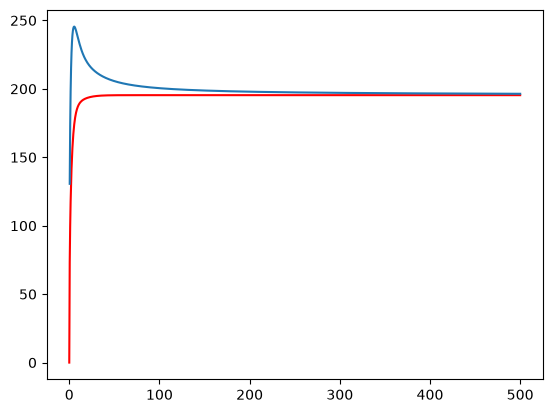

In [3]:
r_grid = np.linspace(0,500,1000)
M_b_inner = M_inner * f(r_grid, Rd_inner)
M_b_outer = M_outer * f(r_grid, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r_grid**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
vc_grid        = np.sqrt(G_kpc * M_c / r_grid)
vc_theo   = (G_kpc * M_b_total * a0_kpc)**0.25
plt.plot(r_grid, vc_theo, color="red")
plt.plot(r_grid, vc_grid)

In [4]:
import pynbody as pn
s = pn.load("/Users/olgahinke/simus/tests_new_MW/one_part/100/output_00001")
print("r units =", s.dm["pos"].units)
print("vel units =", s.dm["vel"].units)
correction = 2.07e+02 #cm/s^-1

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


r units = 3.09e+21 cm
vel units = 2.07e+02 cm s**-1


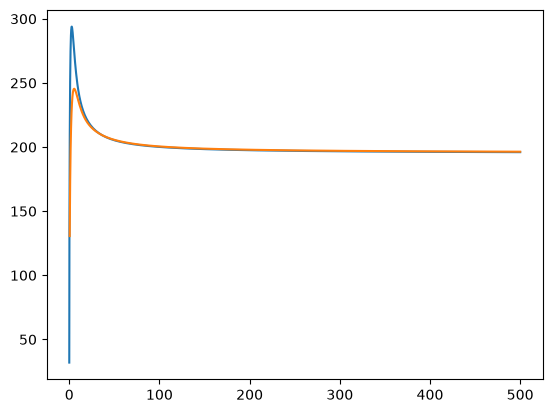

In [5]:
d = "/Users/olgahinke/simus/tests_new_MW/one_part/100/mond_rotation_table.dat"

data = np.loadtxt(d)
r    = data[:, 0]
Mc = data[:, 7]
vc    = data[:, 8]
vc_newt    = data[:, 9]
vc_kms =  vc * correction / 1e5
plt.plot(r, vc_kms)
plt.plot(r_grid, vc_grid)

In [12]:
import pynbody as pn

s1 = pn.load("/Users/olgahinke/simus/tests_new_MW/one_part/100/output_00001")
s2 = pn.load("/Users/olgahinke/simus/tests_new_MW/one_part/100/output_00002")
s1.physical_units()
s2.physical_units()

# positions in kpc, relative to box centre
boxlen = float(s1.properties["boxsize"].in_units("kpc"))
centre = boxlen / 2.0
print(f"boxlen = {boxlen} kpc, centre = {centre} kpc")

pos1 = np.array(s1.dm["pos"].in_units("kpc"))[0] - centre
pos2 = np.array(s2.dm["pos"].in_units("kpc"))[0] - centre
vel1 = np.array(s1.dm["vel"].in_units("km s^-1"))[0]
vel2 = np.array(s2.dm["vel"].in_units("km s^-1"))[0]

t1 = float(s1.properties["time"].in_units("s"))
t2 = float(s2.properties["time"].in_units("s"))
dt_s = t2 - t1

print(f"pos1 = {pos1} kpc")   # should be ~[-100, 0, 0]
print(f"pos2 = {pos2} kpc")
print(f"vel1 = {vel1} km/s")
print(f"vel2 = {vel2} km/s")
print(f"dt   = {dt_s:.4f} s")

kpc_to_km = 3.085678e16   # km per kpc  (not 3.09e13 which is metres!)

r_mag     = np.linalg.norm(pos1)          # kpc
r_mag_km  = r_mag * kpc_to_km             # km

a_num     = (vel2 - vel1) / dt_s          # km/s^2
a_mag     = np.linalg.norm(a_num)         # km/s^2

v_circ_sim = np.sqrt(a_mag * r_mag_km)   # km/s

print(f"r_sat         = {r_mag:.1f} kpc")
print(f"r_sat         = {r_mag_km:.3e} km")
print(f"|a| numerical = {a_mag:.4e} km/s^2")
print(f"v_circ sim    = {v_circ_sim:.1f} km/s")
print(f"v_circ theory = {np.interp(r_mag, r_grid, vc_grid):.1f} km/s")
print(f"ratio         = {v_circ_sim / np.interp(r_mag, r_grid, vc_grid):.3f}")


boxlen = 999.999999516681 kpc, centre = 499.9999997583405 kpc
pos1 = [1.00000000e+02 5.68434189e-14 5.68434189e-14] kpc
pos2 = [9.99848812e+01 1.95312500e+00 5.68434189e-14] kpc
vel1 = [  0.  200.4   0. ] km/s
vel2 = [-1.55125889e+00  2.00400000e+02  2.58566733e-12] km/s
dt   = 300734232706461.7500 s
r_sat         = 100.0 kpc
r_sat         = 3.086e+18 km
|a| numerical = 5.1582e-15 km/s^2
v_circ sim    = 126.2 km/s
v_circ theory = 200.5 km/s
ratio         = 0.629


In [13]:
# Convert to code units
scale_d_cgs = 6.7696e-32   # g/cm^3 per code unit — replace with your actual value
kpc_cm = 3.085678e21
Msun_g = 1.989e33
conv_d = Msun_g / (kpc_cm**3 * scale_d_cgs)

for r_test in [1, 5, 10, 50, 100, 200]:
    rho_phys = (M_inner * np.exp(-r_test/Rd_inner) / (4*np.pi * Rd_inner**2 * r_test) +
                M_outer * np.exp(-r_test/Rd_outer) / (4*np.pi * Rd_outer**2 * r_test))
    rho_code = rho_phys * conv_d
    print(f"r={r_test:4d} kpc: rho_phys={rho_phys:.2e} Msun/kpc3  "
          f"rho_code={rho_code:.2e}  "
          f"{'FLOOR' if rho_code < 1e-5 else 'OK'}")

r=   1 kpc: rho_phys=8.38e+08 Msun/kpc3  rho_code=8.38e+08  OK
r=   5 kpc: rho_phys=2.79e+07 Msun/kpc3  rho_code=2.79e+07  OK
r=  10 kpc: rho_phys=1.87e+06 Msun/kpc3  rho_code=1.87e+06  OK
r=  50 kpc: rho_phys=4.14e+02 Msun/kpc3  rho_code=4.14e+02  OK
r= 100 kpc: rho_phys=1.64e-01 Msun/kpc3  rho_code=1.64e-01  OK
r= 200 kpc: rho_phys=5.12e-08 Msun/kpc3  rho_code=5.12e-08  FLOOR


In [14]:
# What force does the floor density produce at 100 kpc?
floor_code  = 1e-5
floor_phys  = floor_code / conv_d   # Msun/kpc^3

# Enclosed mass from uniform floor out to 100 kpc
M_floor_100 = floor_phys * (4/3) * np.pi * 100**3   # Msun
g_floor_100 = G_kpc * M_floor_100 / 100**2           # (km/s)^2/kpc
v_floor_100 = np.sqrt(g_floor_100 * 100)             # km/s

print(f"Floor density   = {floor_phys:.3e} Msun/kpc^3")
print(f"M_enc(floor,100)= {M_floor_100:.3e} Msun")
print(f"v_c from floor  = {v_floor_100:.1f} km/s")
print(f"v_c expected    = {np.interp(100, r_grid, vc_grid):.1f} km/s")

Floor density   = 1.000e-05 Msun/kpc^3
M_enc(floor,100)= 4.189e+01 Msun
v_c from floor  = 0.0 km/s
v_c expected    = 200.5 km/s


In [15]:
# Expected gN at 100 kpc from your Python profile
r_test   = 100.0   # kpc
gN_100   = G_kpc * np.interp(r_test, r_grid, M_b_total) / r_test**2
g_mond100 = np.interp(r_test, r_grid, vc_grid)**2 / r_test
print(f"Expected gN(100)    = {gN_100:.4e} (km/s)^2/kpc")
print(f"Expected g_MOND(100)= {g_mond100:.4e} (km/s)^2/kpc")
print(f"nu(100)             = {g_mond100/gN_100:.3f}")

# Your simulated acceleration
a_sim_kpc = a_mag * 3.085678e16 / 1e6  # convert km/s^2 to (km/s)^2/kpc
print(f"Simulated g(100)    = {a_sim_kpc:.4e} (km/s)^2/kpc")
print(f"Ratio sim/expected  = {a_sim_kpc/g_mond100:.4f}")

Expected gN(100)    = 3.9353e+01 (km/s)^2/kpc
Expected g_MOND(100)= 4.0192e+02 (km/s)^2/kpc
nu(100)             = 10.213
Simulated g(100)    = 1.5917e-04 (km/s)^2/kpc
Ratio sim/expected  = 0.0000
